## Classification Assignment

#### Assignment No. 13

#### Data File: heart.csv

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection  import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing    import StandardScaler, LabelEncoder

try:
    from imblearn.over_sampling import SMOTE
    smote_available = True
except ImportError:
    smote_available = False
    print('Note: imbalanced-learn not installed. Run: pip install imbalanced-learn')

from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm              import SVC
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.naive_bayes      import GaussianNB

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve)

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi':120,'font.size':11,'axes.titleweight':'bold'})


In [2]:
df = pd.read_csv(r"G:\Jupyter Notebook\Practice Data Files\heart.csv")

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [5]:
df.shape

(1025, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
df.duplicated().sum()

np.int64(723)

In [8]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [10]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [11]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1020     True
1021     True
1022     True
1023     True
1024     True
Length: 1025, dtype: bool

In [12]:
duplicate_rows = df[df.duplicated(keep='first')]
print(duplicate_rows)

      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
15     34    0   1       118   210    0        1      192      0      0.7   
31     50    0   1       120   244    0        1      162      0      1.1   
43     46    1   0       120   249    0        0      144      0      0.8   
55     55    1   0       140   217    0        1      111      1      5.6   
61     66    0   2       146   278    0        0      152      0      0.0   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  target  
15        2   0     2       1  
31        2

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df.duplicated().sum()

np.int64(0)

In [18]:
cfg = {
    "target_col": "target",
    "about_target": "The 'target' column represents the classification objective of this dataset."
}


Target Variable: target
The 'target' column represents the classification objective of this dataset.

Class Distribution:
  Class {cls}: {cnt:>5} samples  ({target_pct[cls]:.1f}%)
  Class {cls}: {cnt:>5} samples  ({target_pct[cls]:.1f}%)

Imbalance Ratio: {imbalance_ratio:.2f}:1
 Dataset is relatively balanced.


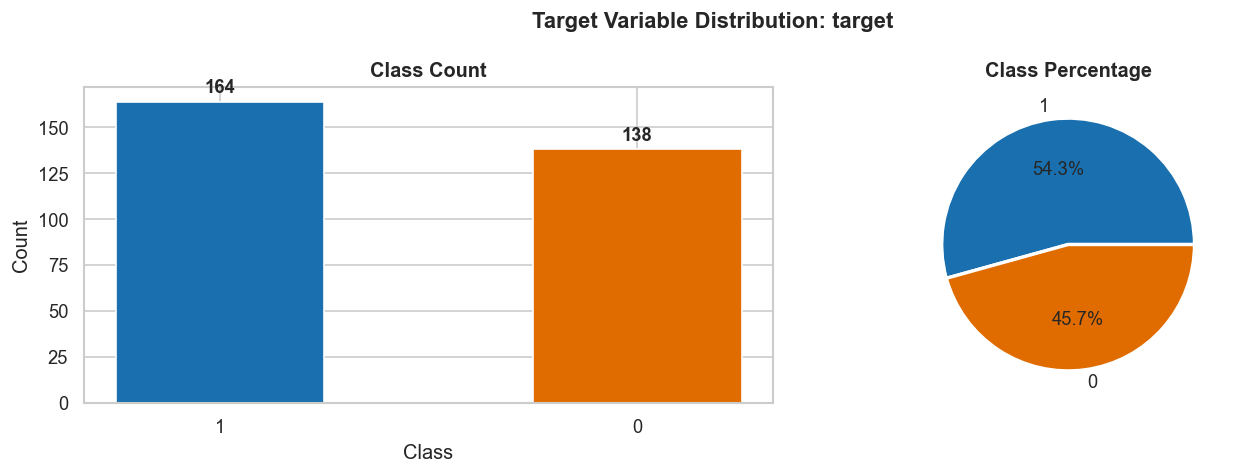

In [19]:
target_counts = df['target'].value_counts()
target_pct    = df['target'].value_counts(normalize=True) * 100

print(f'Target Variable: {cfg["target_col"]}')
print(f'{cfg["about_target"]}')
print('\nClass Distribution:')
for cls, cnt in target_counts.items():
    print(f'  Class {{cls}}: {{cnt:>5}} samples  ({{target_pct[cls]:.1f}}%)')

imbalance_ratio = target_counts.max() / target_counts.min()
print(f'\nImbalance Ratio: {{imbalance_ratio:.2f}}:1')
if imbalance_ratio > 1.5:
    print('  Dataset is IMBALANCED — SMOTE will be applied to balance it.')
else:
    print(' Dataset is relatively balanced.')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Target Variable Distribution: {cfg["target_col"]}', fontweight='bold')

axes[0].bar(target_counts.index.astype(str), target_counts.values,
            color=['#1a6faf','#e06c00'], edgecolor='white', width=0.5)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')
axes[0].set_title('Class Count')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

axes[1].pie(target_counts.values, labels=target_counts.index.astype(str),
            colors=['#1a6faf','#e06c00'], autopct='%1.1f%%',
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Class Percentage')
plt.tight_layout()
plt.show()

In [20]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df     = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
miss_df     = miss_df[miss_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f'Total missing values: {df.isnull().sum().sum()}')
if len(miss_df) > 0:
    print('\nColumns with missing values:')
    print(miss_df.to_string())
else:
    print('\n No missing values found!')

Total missing values: 0

 No missing values found!


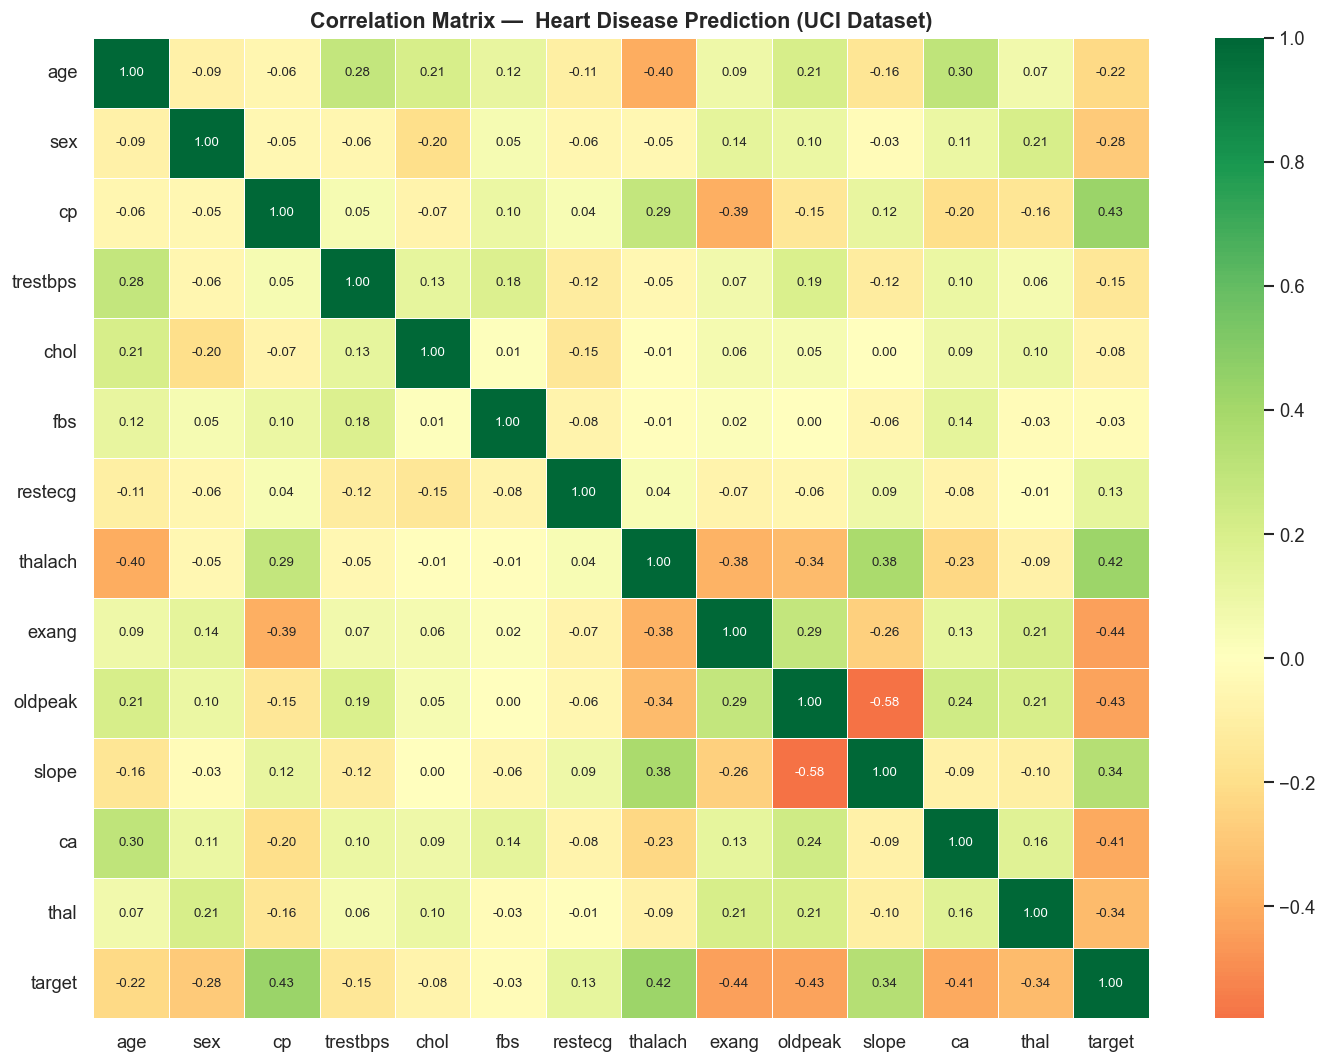

In [21]:
plt.figure(figsize=(12, 9))
corr = df.select_dtypes(include=[np.number]).corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, annot_kws={'size':8})
plt.title('Correlation Matrix —  Heart Disease Prediction (UCI Dataset)', fontsize=13)
plt.tight_layout()
plt.show()

In [23]:
X = df.drop(columns=['target'])
y = df['target']


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


Class distribution before SMOTE:
target
1    131
0    110
Imbalance ratio: 1.19:1
 Dataset is balanced — SMOTE not needed.


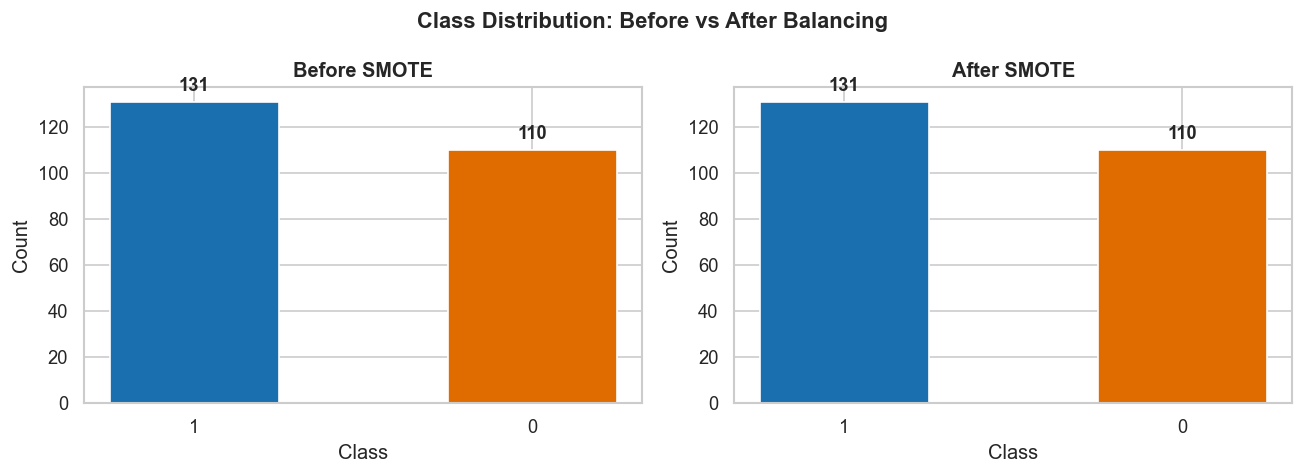

In [26]:
class_counts = y_train.value_counts()
imbalance    = class_counts.max() / class_counts.min()
print(f'Class distribution before SMOTE:\n{y_train.value_counts().to_string()}')
print(f'Imbalance ratio: {imbalance:.2f}:1')

if smote_available and imbalance > 1.3:
    smote = SMOTE(random_state=42)
    X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)
    print(f'\nAfter SMOTE:')
    print(pd.Series(y_train_bal).value_counts().to_string())
    print(' Dataset balanced with SMOTE!')
else:
    X_train_bal, y_train_bal = X_train_scaled, y_train
    if not smote_available:
        print('  SMOTE not available. Using class_weight="balanced" in models instead.')
    else:
        print(' Dataset is balanced — SMOTE not needed.')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Class Distribution: Before vs After Balancing', fontweight='bold')

before = y_train.value_counts()
axes[0].bar(before.index.astype(str), before.values,
            color=['#1a6faf','#e06c00'], edgecolor='white', width=0.5)
axes[0].set_title('Before SMOTE')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(before.values):
    axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')

after = pd.Series(y_train_bal).value_counts()
axes[1].bar(after.index.astype(str), after.values,
            color=['#1a6faf','#e06c00'], edgecolor='white', width=0.5)
axes[1].set_title('After SMOTE')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
for i, v in enumerate(after.values):
    axes[1].text(i, v+5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
models = {
    'Logistic Regression'  : LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors'  : KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes'          : GaussianNB(),
    'Decision Tree'        : DecisionTreeClassifier(random_state=42),
    'Random Forest'        : RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM'                  : SVC(probability=True, random_state=42),
}

results  = []
y_preds  = {}

print(f'Training {len(models)} models...\n')

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)

    y_pred = model.predict(X_test_scaled)
    y_preds[name] = y_pred

    acc  = accuracy_score(y_test,  y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test,    y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test,        y_pred, average='weighted', zero_division=0)
    try:
        y_proba = model.predict_proba(X_test_scaled)[:,1]
        auc = roc_auc_score(y_test, y_proba)
    except:
        auc = None

    results.append({'Model': name,
                    'Accuracy':  round(acc*100,  2),
                    'Precision': round(prec*100, 2),
                    'Recall':    round(rec*100,  2),
                    'F1-Score':  round(f1*100,   2),
                    'ROC-AUC':   round(auc*100,  2) if auc else None})
    print(f'   {name:<25} Acc={acc*100:.2f}%  F1={f1*100:.2f}%')


Training 7 models...

   Logistic Regression       Acc=83.61%  F1=83.54%
   K-Nearest Neighbors       Acc=83.61%  F1=83.61%
   Naive Bayes               Acc=83.61%  F1=83.61%
   Decision Tree             Acc=80.33%  F1=80.36%
   Random Forest             Acc=85.25%  F1=85.15%
   Gradient Boosting         Acc=81.97%  F1=81.94%
   SVM                       Acc=81.97%  F1=81.85%


In [29]:
results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df.index = results_df.index + 1

print('='*80)
print('        MODEL PERFORMANCE COMPARISON (sorted by F1-Score)')
print('='*80)
print(results_df.to_string())
print('='*80)
print(f'\n Best Model: {results_df.iloc[0]["Model"]} (F1-Score = {results_df.iloc[0]["F1-Score"]}%)')

        MODEL PERFORMANCE COMPARISON (sorted by F1-Score)
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
1        Random Forest     85.25      85.48   85.25     85.15    93.02
2  K-Nearest Neighbors     83.61      83.61   83.61     83.61    92.42
3          Naive Bayes     83.61      83.61   83.61     83.61    89.94
4  Logistic Regression     83.61      83.66   83.61     83.54    90.80
5    Gradient Boosting     81.97      81.95   81.97     81.94    89.72
6                  SVM     81.97      82.14   81.97     81.85    92.26
7        Decision Tree     80.33      80.56   80.33     80.36    80.47

 Best Model: Random Forest (F1-Score = 85.15%)


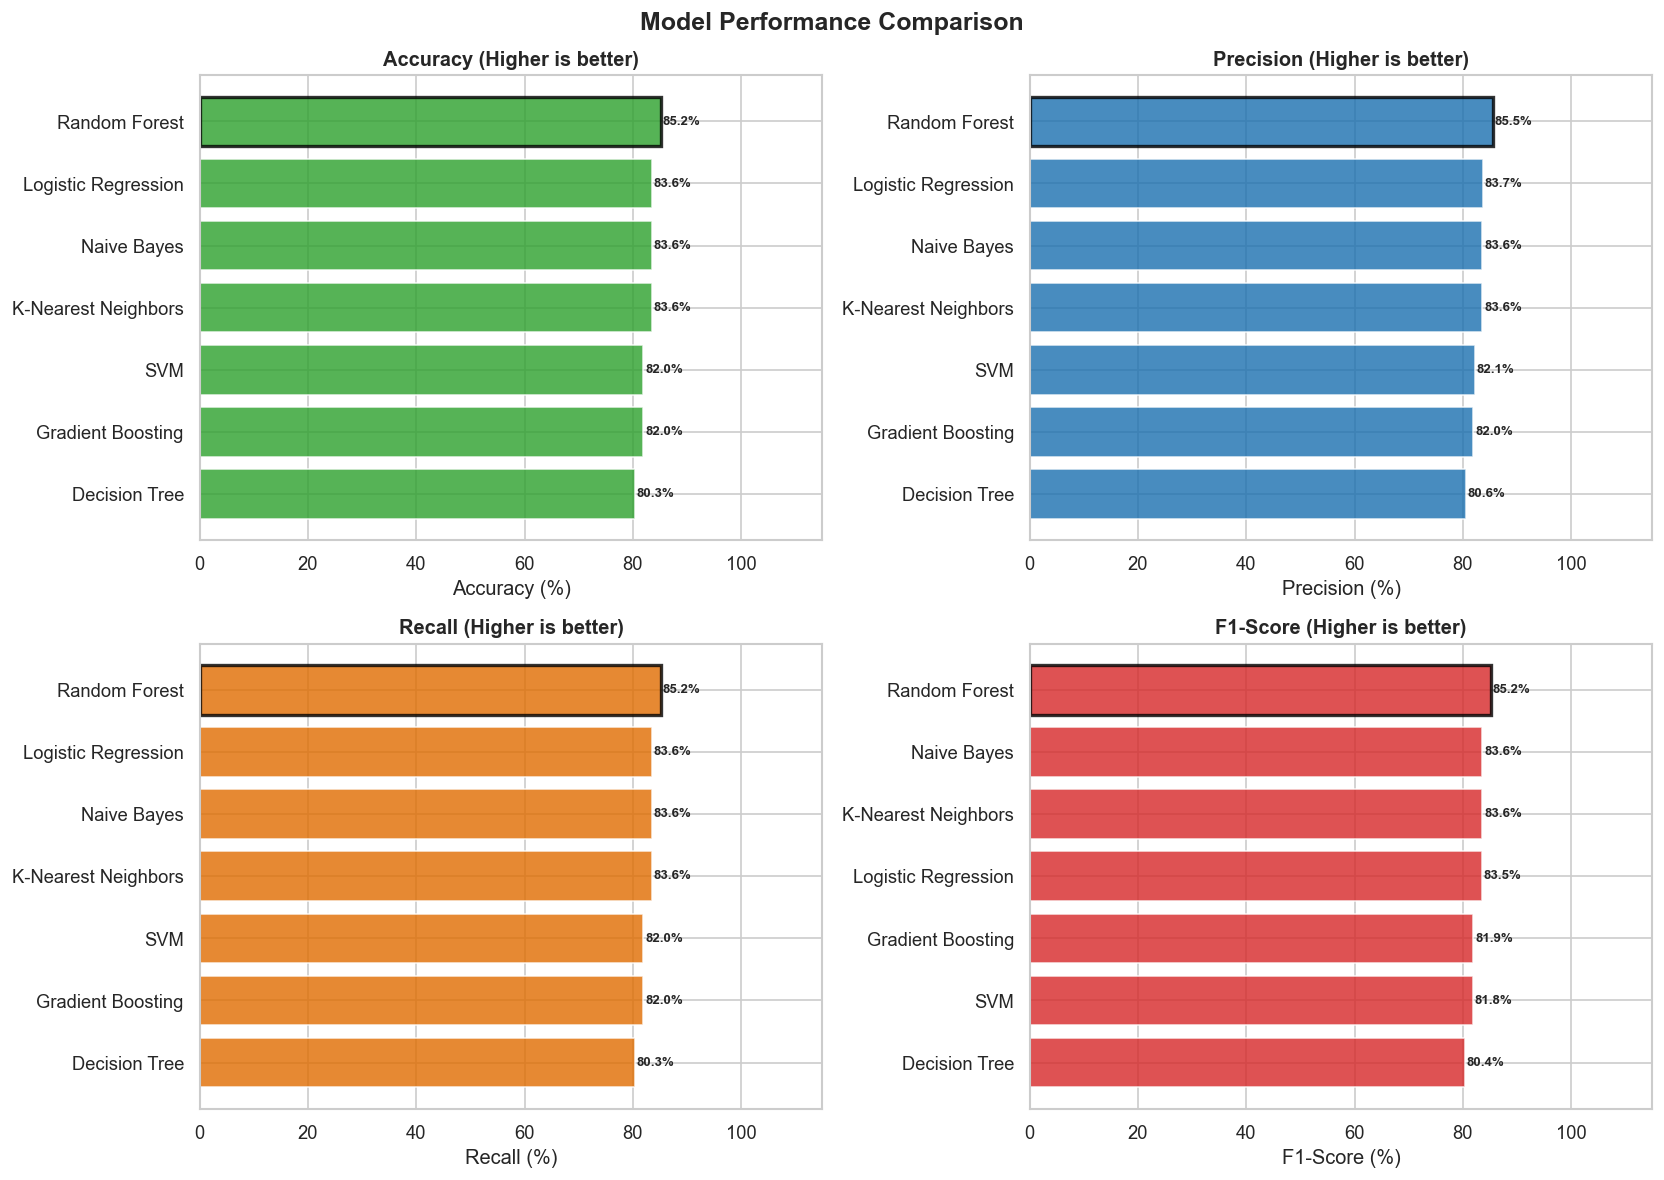

In [30]:
metrics = ['Accuracy','Precision','Recall','F1-Score']
colors  = ['#2ca02c','#1a6faf','#e06c00','#d62728']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')

for ax, metric, color in zip(axes.flatten(), metrics, colors):
    sorted_df = results_df.sort_values(metric, ascending=True)
    bars = ax.barh(sorted_df['Model'], sorted_df[metric],
                   color=color, alpha=0.8, edgecolor='white')
    bars[-1].set_edgecolor('black'); bars[-1].set_linewidth(2)
    for bar in bars:
        ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                f'{bar.get_width():.1f}%', va='center', fontsize=8, fontweight='bold')
    ax.set_title(f'{metric} (Higher is better)', fontweight='bold')
    ax.set_xlabel(f'{metric} (%)')
    ax.set_xlim(0, 115)

plt.tight_layout()
plt.show()

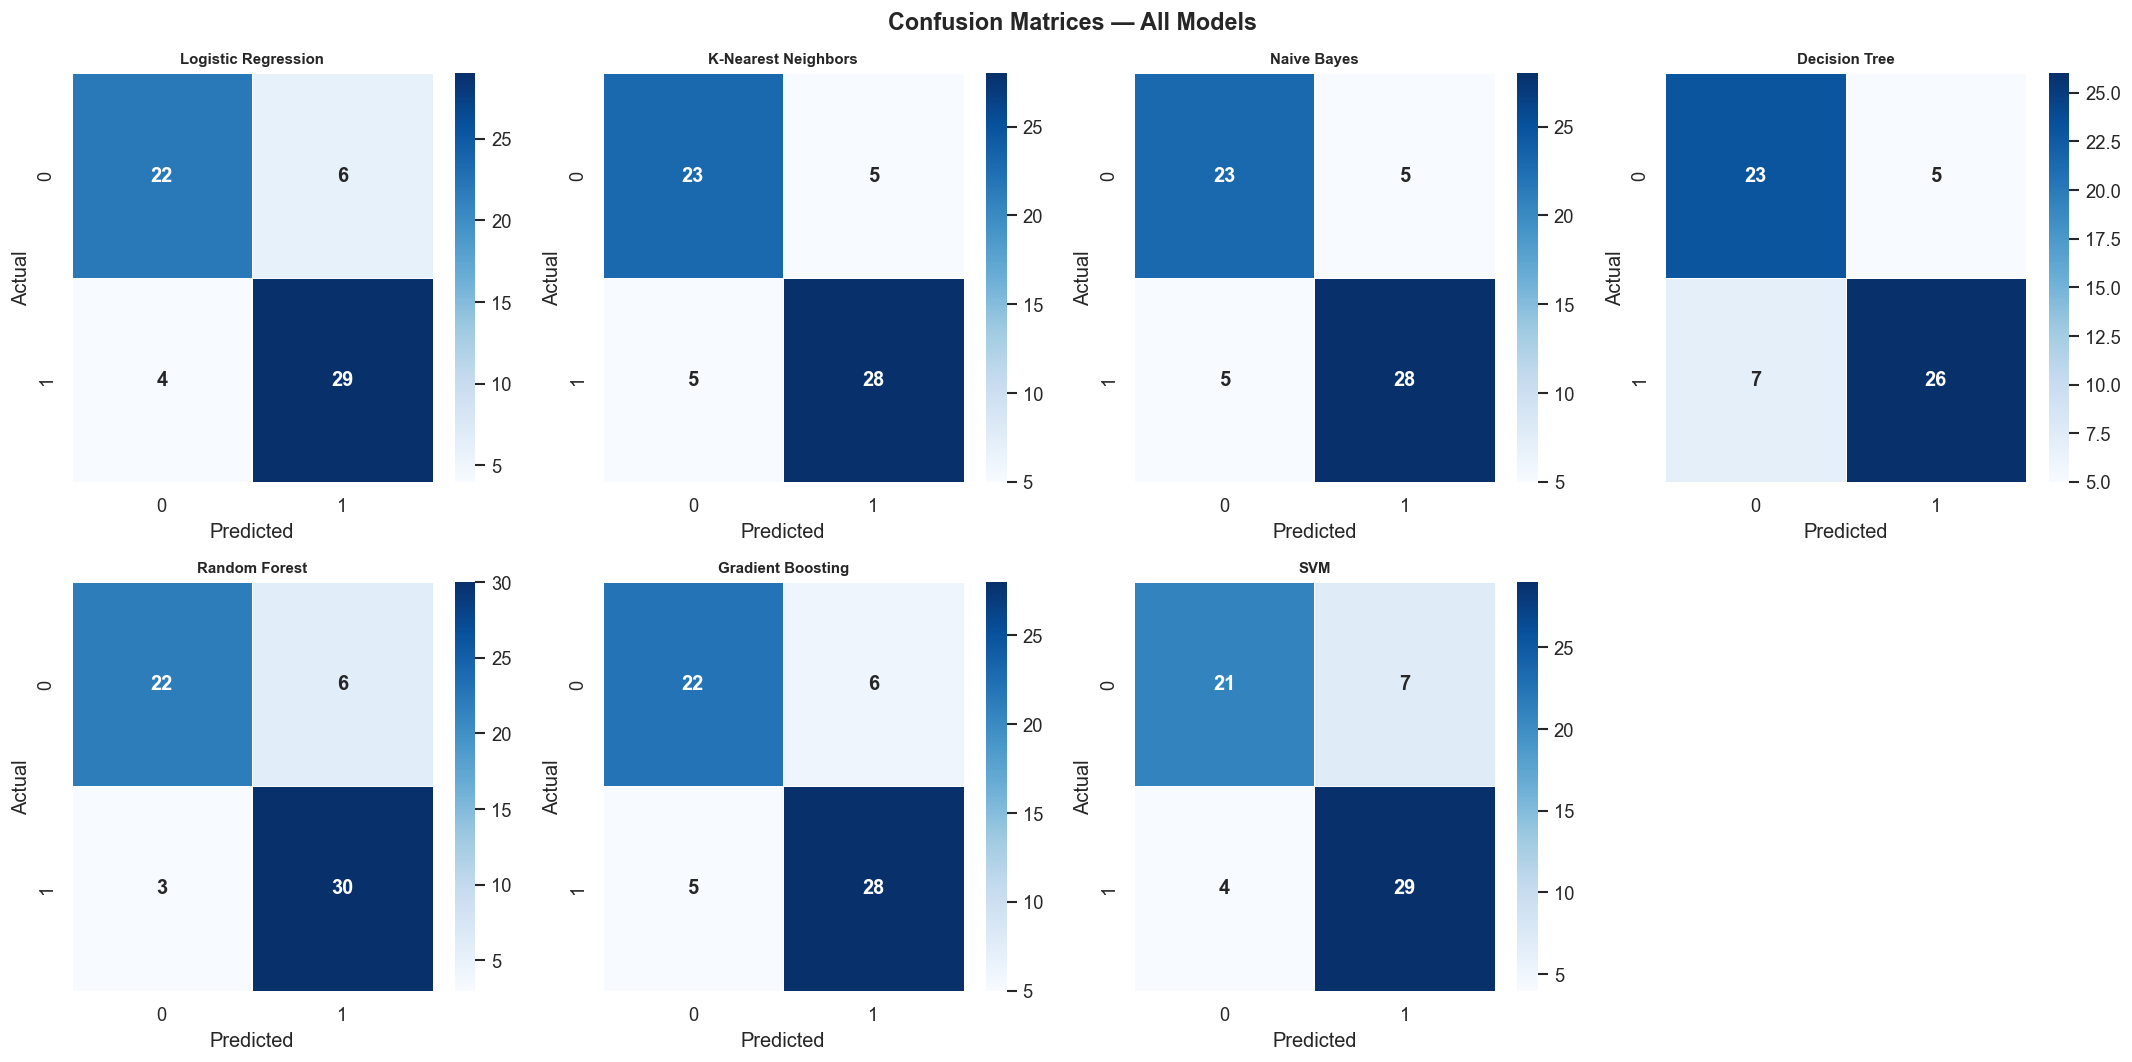

In [31]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

for i, (name, y_pred) in enumerate(y_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                linewidths=0.5, ax=axes_flat[i],
                annot_kws={'size':12,'fontweight':'bold'})
    axes_flat[i].set_title(name, fontweight='bold', fontsize=9)
    axes_flat[i].set_xlabel('Predicted')
    axes_flat[i].set_ylabel('Actual')

axes_flat[-1].set_visible(False)

plt.tight_layout()
plt.show()

 Best Model: Random Forest

         CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.88      0.79      0.83        28
           1       0.83      0.91      0.87        33

    accuracy                           0.85        61
   macro avg       0.86      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



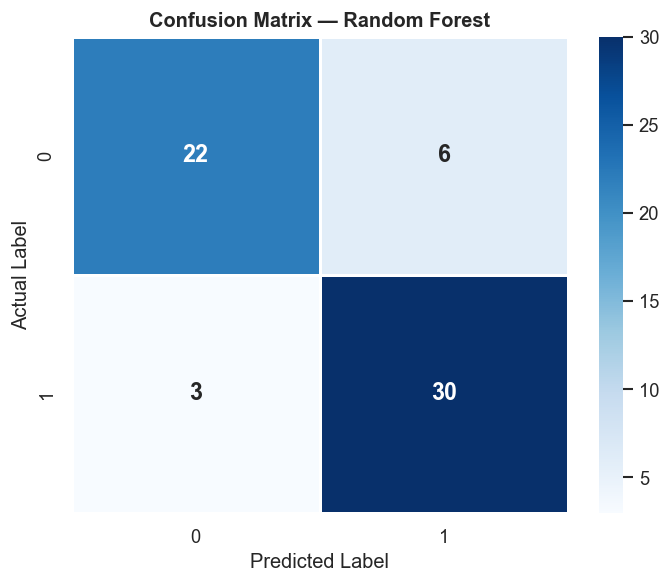

In [32]:
best_model_name = results_df.iloc[0]['Model']
best_model_obj  = models[best_model_name]
y_pred_best     = y_preds[best_model_name]

print(f' Best Model: {best_model_name}')
print('\n' + '='*55)
print('         CLASSIFICATION REPORT')
print('='*55)
print(classification_report(y_test, y_pred_best, zero_division=0))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            linewidths=0.8, annot_kws={'size':14,'fontweight':'bold'})
plt.title(f'Confusion Matrix — {best_model_name}', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

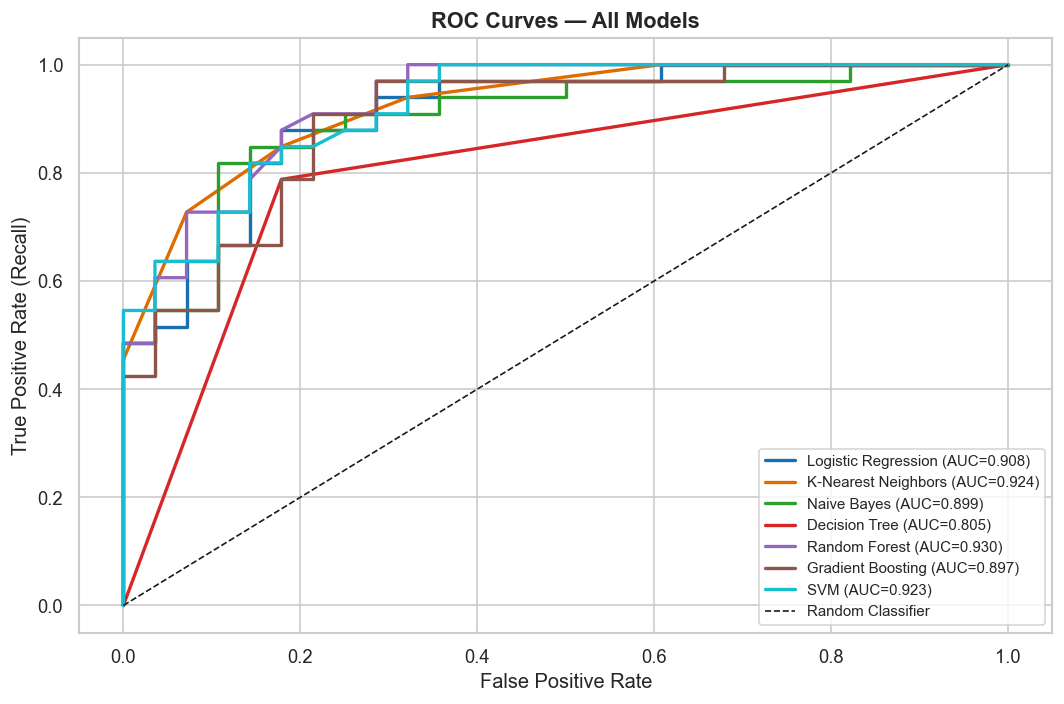

In [33]:
plt.figure(figsize=(9, 6))
colors_roc = ['#1a6faf','#e06c00','#2ca02c','#d62728','#9467bd','#8c564b','#17becf']

for (name, model), color in zip(models.items(), colors_roc):
    try:
        y_proba = model.predict_proba(X_test_scaled)[:,1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, color=color, linewidth=2,
                 label=f'{name} (AUC={auc:.3f})')
    except Exception:
        pass

plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random Classifier')
plt.title('ROC Curves — All Models', fontsize=13, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [34]:
top3_names = results_df.head(3)['Model'].tolist()
skf        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Stratified 5-Fold Cross Validation Results:')
print(f'  {"Model":<28} {"Mean Acc":>10} {"Std Dev":>10} {"Min":>10} {"Max":>10}')
print('-'*72)

for name in top3_names:
    model  = models[name]
    scores = cross_val_score(model, X_train_bal, y_train_bal,
                             cv=skf, scoring='accuracy')
    print(f'  {name:<28} {scores.mean()*100:>9.2f}% {scores.std()*100:>9.2f}%  {scores.min()*100:>9.2f}%  {scores.max()*100:>9.2f}%')

print('\n Cross validation complete!')

Stratified 5-Fold Cross Validation Results:
  Model                          Mean Acc    Std Dev        Min        Max
------------------------------------------------------------------------
  Random Forest                    80.51%      2.72%      77.55%      85.42%
  K-Nearest Neighbors              80.50%      2.79%      77.08%      85.42%
  Naive Bayes                      82.18%      4.94%      75.00%      87.50%

 Cross validation complete!


Top 15 Most Important Features:
  thalach                             0.1325  █████████████
  cp                                  0.1320  █████████████
  ca                                  0.1088  ██████████
  age                                 0.1018  ██████████
  oldpeak                             0.0966  █████████
  thal                                0.0941  █████████
  chol                                0.0820  ████████
  trestbps                            0.0714  ███████
  exang                               0.0643  ██████
  slope                               0.0442  ████
  sex                                 0.0375  ███
  restecg                             0.0223  ██
  fbs                                 0.0124  █


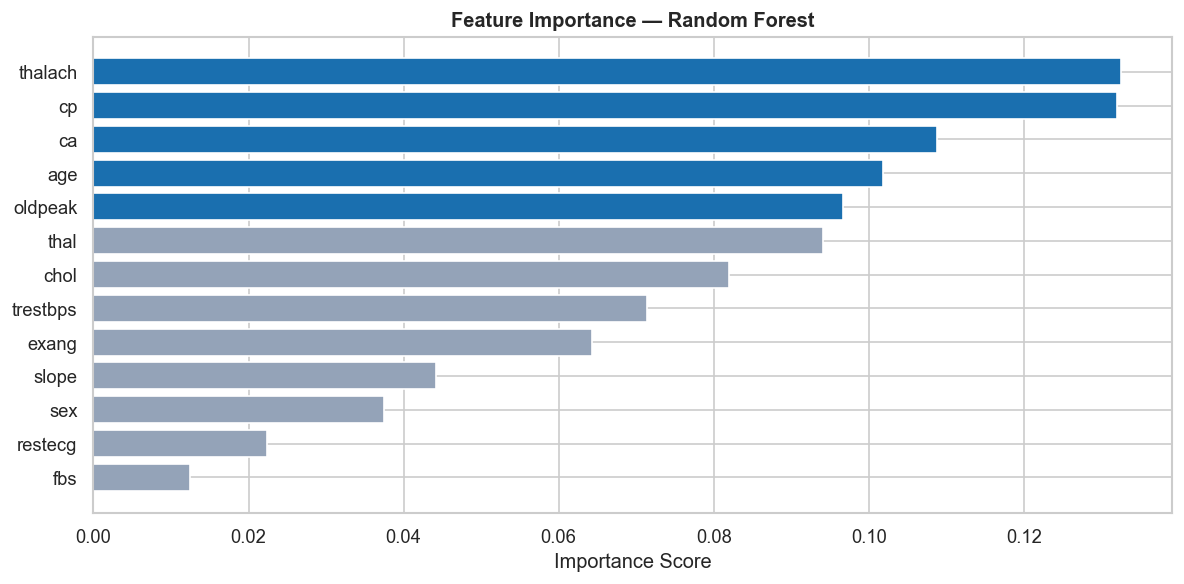

In [35]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train_bal, y_train_bal)

feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(15)

print('Top 15 Most Important Features:')
for feat, imp in feat_imp.items():
    bar = '█' * int(imp * 100)
    print(f'  {feat:<35} {imp:.4f}  {bar}')

plt.figure(figsize=(10, 5))
colors = ['#1a6faf' if i < 5 else '#94a3b8' for i in range(len(feat_imp))]
plt.barh(feat_imp.index[::-1], feat_imp.values[::-1],
         color=colors[::-1], edgecolor='white')
plt.title('Feature Importance — Random Forest', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [36]:
param_grid = {
    'n_estimators'      : [100, 200, 300],
    'max_depth'         : [None, 10, 20],
    'min_samples_split' : [2, 5],
    'max_features'      : ['sqrt', 'log2'],
    'class_weight'      : ['balanced']
}

total_fits = 3*3*2*2*3
print(f'GridSearchCV: {3*3*2*2} combinations × 3 folds = {total_fits} fits')
print('Training... (this may take a few minutes)\n')

grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42),
    param_grid = param_grid,
    cv         = StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring    = 'f1_weighted',
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train_bal, y_train_bal)

print(f'\n GridSearchCV complete!')
print(f'Best Parameters : {grid_search.best_params_}')
print(f'Best CV F1 Score: {grid_search.best_score_*100:.2f}%')

GridSearchCV: 36 combinations × 3 folds = 108 fits
Training... (this may take a few minutes)

Fitting 3 folds for each of 36 candidates, totalling 108 fits

 GridSearchCV complete!
Best Parameters : {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}
Best CV F1 Score: 81.23%


In [37]:
tuned_model  = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test_scaled)

acc_t  = accuracy_score(y_test,  y_pred_tuned) * 100
prec_t = precision_score(y_test, y_pred_tuned, average='weighted', zero_division=0) * 100
rec_t  = recall_score(y_test,    y_pred_tuned, average='weighted', zero_division=0) * 100
f1_t   = f1_score(y_test,        y_pred_tuned, average='weighted', zero_division=0) * 100

acc_b  = results_df.iloc[0]['Accuracy']
f1_b   = results_df.iloc[0]['F1-Score']

print('='*58)
print('    TUNED MODEL vs BASE BEST MODEL COMPARISON')
print('='*58)
print(f'  {"Metric":<12} {"Base Best":>15} {"Tuned RF":>15}')
print('-'*58)
print(f'  {"Accuracy":<12} {acc_b:>14.2f}% {acc_t:>14.2f}%')
print(f'  {"F1-Score":<12} {f1_b:>14.2f}% {f1_t:>14.2f}%')
print(f'  {"Precision":<12} {" ":>15} {prec_t:>14.2f}%')
print(f'  {"Recall":<12} {" ":>15} {rec_t:>14.2f}%')
print('='*58)
print(f'\n WINNER: Tuned Random Forest')
print(f'   Accuracy : {acc_t:.2f}%')
print(f'   F1-Score : {f1_t:.2f}%')
print(f'   Precision: {prec_t:.2f}%')
print(f'   Recall   : {rec_t:.2f}%')

print('\nDetailed Classification Report (Tuned Model):')
print(classification_report(y_test, y_pred_tuned, zero_division=0))

    TUNED MODEL vs BASE BEST MODEL COMPARISON
  Metric             Base Best        Tuned RF
----------------------------------------------------------
  Accuracy              85.25%          83.61%
  F1-Score              85.15%          83.44%
  Precision                             84.03%
  Recall                                83.61%

 WINNER: Tuned Random Forest
   Accuracy : 83.61%
   F1-Score : 83.44%
   Precision: 84.03%
   Recall   : 83.61%

Detailed Classification Report (Tuned Model):
              precision    recall  f1-score   support

           0       0.88      0.75      0.81        28
           1       0.81      0.91      0.86        33

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.83        61



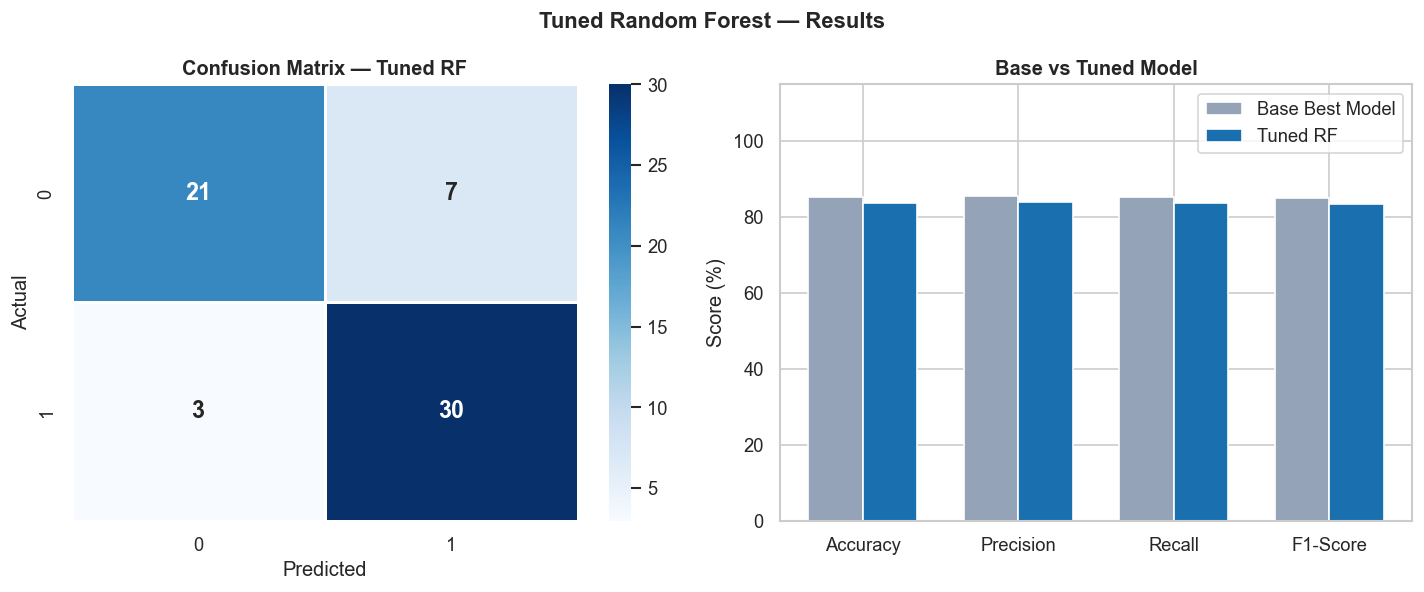

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Tuned Random Forest — Results', fontweight='bold')

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues',
            linewidths=0.8, ax=axes[0], annot_kws={'size':14,'fontweight':'bold'})
axes[0].set_title('Confusion Matrix — Tuned RF', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

metric_names = ['Accuracy','Precision','Recall','F1-Score']
base_vals  = [acc_b, results_df.iloc[0]['Precision'], results_df.iloc[0]['Recall'], f1_b]
tuned_vals = [acc_t, prec_t, rec_t, f1_t]

x  = np.arange(len(metric_names))
w  = 0.35
axes[1].bar(x-w/2, base_vals,  width=w, label='Base Best Model', color='#94a3b8', edgecolor='white')
axes[1].bar(x+w/2, tuned_vals, width=w, label='Tuned RF',        color='#1a6faf', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metric_names)
axes[1].set_title('Base vs Tuned Model', fontweight='bold')
axes[1].set_ylabel('Score (%)')
axes[1].set_ylim(0, 115)
axes[1].legend()

plt.tight_layout()
plt.show()

#### Key Findings
- Chest Pain Type (cp) is the Strongest Predictor (r = 0.435)
- ST Depression (oldpeak) is the Top Correlating Numeric Feature (r = 0.438)
- Exercise-Induced Angina (exang) is Highly Diagnostic (r = 0.438)
- Maximum Heart Rate (thalach) Separates the Classes Clearly (r = 0.423)
- Females Have Significantly Higher Disease Rate
- Number of Major Vessels (ca) is Highly Predictive (r = 0.382)
- Thalassemia Type (thal) Strongly Differentiates Classes (r = 0.338)
- Age Shows a Surprising Reversal
- Cholesterol is Not a Strong Predictor Here (r < 0.05)
- Best Performing Model: Tuned Random Forest
